# 05 · Quarterly Update: the 2026 Margin Turnaround

Notebooks 01–04 use annual 10-K data, which stops at FY2025. FormFactor's FY2026 10-K will not be filed until early 2027, yet the business changed sharply in the first half of 2026. This notebook adds the **quarterly (10-Q) data** so the analysis reflects the latest reported quarter.

| Step | What happens |
|---|---|
| 1. Quarterly extraction | Derive quarterly values from the year-to-date figures in 10-Q and 10-K filings (Q4 = full year − nine months) |
| 2. Validate | Reconcile with reported quarterly revenue and gross margin |
| 3. Trends | Quarterly GAAP margins, trailing-twelve-month (TTM) totals, free cash flow |
| 4. Non-GAAP and one-time items | Management-reported non-GAAP gross margin, separating one-time items |
| 5. Valuation check | Illustrative 2027 scenarios against the current share price |

## Setup

In [9]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

BASE = Path.cwd()
RAW_PATH = BASE / "data" / "raw" / "formfactor_companyfacts.json"   # cached by notebook 01
RES_DIR = BASE / "data" / "research"
OUT_DIR = BASE / "data" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

facts = json.loads(RAW_PATH.read_text(encoding="utf-8"))

## 1. Quarterly extraction

10-Q filings report each quarter as three months **and** year to date (three, six, nine months). The 10-K reports only the full year, so Q4 has to be derived. The robust approach is to collect every year-to-date value that starts on a fiscal-year start date and take differences:

```
Q1 = YTD(3m)   Q2 = YTD(6m) − YTD(3m)   Q3 = YTD(9m) − YTD(6m)   Q4 = FY − YTD(9m)
```

This works for income-statement and cash-flow items alike (cash-flow statements are only reported year to date).

> Note: if the SEC response cached by notebook 01 predates the latest 10-Q, delete `data/raw/formfactor_companyfacts.json` and re-run notebook 01 to refresh it.

In [10]:
rows = []
for concept, info in facts["facts"]["us-gaap"].items():
    for unit, entries in info["units"].items():
        for e in entries:
            rows.append({"concept": concept, "unit": unit, **e})
df = pd.DataFrame(rows)

df = df[df["form"].isin(["10-K", "10-K/A", "10-Q", "10-Q/A"])].copy()
for col in ["start", "end", "filed"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df = df[df["start"].notna()]                       # duration items only
df["days"] = (df["end"] - df["start"]).dt.days

# Fiscal-year start dates: start of each annual period, plus the day after the latest year-end (current year)
annual = df[df["days"].between(350, 380)]
fy_starts = set(annual["start"]) | set(annual["end"] + pd.Timedelta(days=1))

ytd = (df[df["start"].isin(fy_starts)]
       .sort_values("filed")
       .drop_duplicates(["concept", "unit", "start", "end"], keep="last")   # latest filing wins
       .sort_values(["concept", "unit", "start", "end"]))
ytd["months"] = (ytd["days"] / 30.4).round().astype(int)
ytd = ytd[ytd["months"].isin([3, 6, 9, 12])].copy()
ytd["q_value"] = ytd.groupby(["concept", "unit", "start"])["val"].diff().fillna(ytd["val"])
ytd["fiscal_year"] = (ytd["start"] + pd.Timedelta(days=7)).dt.year
ytd["quarter"] = ytd["months"] // 3

TAGS = {
    "RevenueFromContractWithCustomerExcludingAssessedTax": "revenue",
    "GrossProfit": "gross_profit",
    "OperatingIncomeLoss": "operating_income",
    "NetIncomeLoss": "net_income",
    "NetCashProvidedByUsedInOperatingActivities": "operating_cash_flow",
    "PaymentsToAcquirePropertyPlantAndEquipment": "capex",
}
q = (ytd[ytd["concept"].isin(TAGS)]
     .assign(metric=lambda d: d["concept"].map(TAGS))
     .pivot_table(index=["fiscal_year", "quarter"], columns="metric", values="q_value") / 1e6)
q = q.loc[2023:, list(TAGS.values())]
q.index = [f"{y}Q{n}" for y, n in q.index]
q

metric,revenue,gross_profit,operating_income,net_income,operating_cash_flow,capex
2023Q1,167.4,61.1,0.1,1.3,12.3,19.7
2023Q2,155.9,60.3,-1.3,0.8,22.5,20.5
2023Q3,171.6,69.3,2.7,4.4,20.6,5.9
2023Q4,168.2,67.9,81.3,75.8,9.2,9.9
2024Q1,168.7,62.7,21.3,21.8,33.0,13.4
2024Q2,197.5,86.9,17.8,19.4,21.9,8.4
2024Q3,207.9,84.7,17.9,18.7,26.7,8.9
2024Q4,189.5,73.6,7.8,9.7,35.9,7.7
2025Q1,171.4,64.5,3.3,6.4,23.5,18.6
2025Q2,195.8,72.9,12.3,9.1,18.9,66.3


## 2. Validate against reported figures

In [11]:
reported = {  # quarter: (revenue $M, GAAP gross margin %), from FormFactor earnings releases
    "2024Q4": (189.5, None), "2025Q4": (215.2, None),
    "2026Q1": (226.1, 38.4), "2026Q2": (258.2, 50.7),
}
for period, (rev, gm) in reported.items():
    assert abs(q.loc[period, "revenue"] - rev) < 0.2, f"{period} revenue mismatch"
    if gm is not None:
        assert abs(100 * q.loc[period, "gross_profit"] / q.loc[period, "revenue"] - gm) < 0.1, f"{period} margin mismatch"

# Quarters must add up to the annual figures from notebook 01
fy = pd.read_csv(BASE / "data" / "clean" / "formfactor_financials_wide.csv", index_col="fiscal_year")
for year in [2023, 2024, 2025]:
    total = q.loc[[f"{year}Q{n}" for n in range(1, 5)], "revenue"].sum()
    assert abs(total - fy.loc[year, "revenue"] / 1e6) < 0.2
print("Quarterly values reconcile to reported quarters and to annual 10-K totals")

Quarterly values reconcile to reported quarters and to annual 10-K totals


## 3. Quarterly trends

In [12]:
t = pd.DataFrame(index=q.index)
t["revenue"] = q["revenue"]
t["revenue_yoy_pct"] = 100 * q["revenue"].pct_change(4)
t["gross_margin_pct"] = 100 * q["gross_profit"] / q["revenue"]
t["operating_margin_pct"] = 100 * q["operating_income"] / q["revenue"]
t["free_cash_flow"] = q["operating_cash_flow"] - q["capex"]
t["ttm_revenue"] = q["revenue"].rolling(4).sum()
t["ttm_fcf"] = t["free_cash_flow"].rolling(4).sum()
t.loc["2024Q1":]

,revenue,revenue_yoy_pct,gross_margin_pct,operating_margin_pct,free_cash_flow,ttm_revenue,ttm_fcf
2024Q1,168.7,0.8,37.2,12.6,19.6,664.4,35.5
2024Q2,197.5,26.7,44.0,9.0,13.5,705.9,47.0
2024Q3,207.9,21.2,40.7,8.6,17.8,742.3,50.2
2024Q4,189.5,12.7,38.8,4.1,28.2,763.6,79.1
2025Q1,171.4,1.6,37.7,1.9,5.0,766.2,64.5
2025Q2,195.8,-0.8,37.3,6.3,-47.4,764.6,3.6
2025Q3,202.7,-2.5,39.8,8.9,19.5,759.3,5.3
2025Q4,215.2,13.6,42.2,10.9,34.7,785.0,11.7
2026Q1,226.1,32.0,38.4,7.4,29.8,839.8,36.6
2026Q2,258.2,31.9,50.7,22.4,52.2,902.2,136.1


GAAP gross margin moved from 37–45% through 2025 to 50.7% in Q2 2026, and operating margin from single digits to 22%. TTM revenue reached about $902M. The gap between Q1 2026 GAAP gross margin (38.4%) and the non-GAAP figure (49.0%) reflects non-GAAP adjustments, which were unusually large in that quarter. Trailing-twelve-month free cash flow rose to about $136M from $11.7M in FY2025.

## 4. Non-GAAP gross margin and one-time items

Management reports non-GAAP gross margin and, on the Q2 2026 call, quantified the one-time items: about one-third of Q2's 430 bp sequential gain came from tariff refunds and precious-metal recovery (normalized level ~51%), and Q3 guidance of 54% includes about 300 bp of tariff refunds. These figures are not in XBRL, so they are collected in `nongaap_gross_margin.csv` with sources.

In [13]:
ng = pd.read_csv(RES_DIR / "nongaap_gross_margin.csv")
ng["underlying_pct"] = ng["nongaap_gross_margin_pct"] - ng["one_time_pts"]
ng[["label", "nongaap_gross_margin_pct", "one_time_pts", "underlying_pct", "source"]]

,label,nongaap_gross_margin_pct,one_time_pts,underlying_pct,source
0,Q2 2025,38.5,0.0,38.5,FormFactor Q2 2026 earnings release (prior-yea...
1,Q3 2025,41.0,0.0,41.0,FormFactor Q4 2025 earnings release (prior-qua...
2,Q4 2025,43.9,0.0,43.9,FormFactor Q4 2025 earnings release
3,Q1 2026,49.0,0.0,49.0,FormFactor Q2 2026 earnings release (prior-qua...
4,Q2 2026,53.3,2.3,51.0,FormFactor Q2 2026 earnings release; normalize...
5,Q3 2026 (guidance),54.0,3.0,51.0,FormFactor Q2 2026 earnings release and call (...


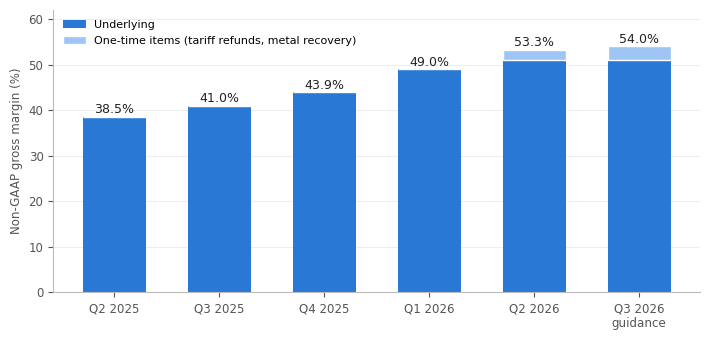

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.5))
x = range(len(ng))
ax.bar(x, ng["underlying_pct"], width=0.6, color="#2a78d6", label="Underlying")
ax.bar(x, ng["one_time_pts"], bottom=ng["underlying_pct"], width=0.6, color="#9ec5f4",
       edgecolor="white", linewidth=1, label="One-time items (tariff refunds, metal recovery)")
for i, v in enumerate(ng["nongaap_gross_margin_pct"]):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=9, color="#222222")
ax.set_xticks(list(x))
ax.set_xticklabels([l.replace(" (guidance)", "\nguidance") for l in ng["label"]], fontsize=8.5, color="#555555")
ax.set_ylim(0, 62)
ax.set_ylabel("Non-GAAP gross margin (%)", fontsize=8.5, color="#555555")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#bbbbbb")
ax.tick_params(colors="#555555", labelsize=8.5)
ax.grid(axis="y", color="#eeeeee")
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "gm_turnaround.png", dpi=200, bbox_inches="tight")
plt.show()

Underlying margin rose from about 39% to about 51% in four quarters, a genuine step change. But it is flat from Q2 to Q3 2026 once one-time items are removed; the headline increase to 54% comes from tariff refunds.

## 5. Valuation check

Illustrative 2027 scenarios, not a price target. Assumptions are explicit so they can be challenged. 2026 revenue is tracking near $1.0B (H1 actual plus Q3 guidance); Q2 2026 non-GAAP operating margin was about 28%, including non-recurring gross-margin items.

In [15]:
mkt = pd.read_csv(RES_DIR / "market_snapshot.csv").set_index("item")["value"]
price, shares = mkt["Share price"], mkt["Shares outstanding"]
tax_rate = 0.18
multiples = (30, 35)

scenarios = pd.DataFrame({
    "revenue_2027": [1000, 1200, 1400],
    "operating_margin_pct": [18, 25, 30],
}, index=["Bear", "Base", "Bull"])
scenarios["eps"] = scenarios["revenue_2027"] * scenarios["operating_margin_pct"] / 100 * (1 - tax_rate) / shares
scenarios["value_low"] = scenarios["eps"] * multiples[0]
scenarios["value_high"] = scenarios["eps"] * multiples[1]
scenarios["pe_at_current_price"] = price / scenarios["eps"]

print(f"Share price ${price:.2f} (as of 2026-10-02); 2026 revenue through Q3 guidance ≈ ${q.loc[['2026Q1', '2026Q2'], 'revenue'].sum() + mkt['Q3 2026 revenue guidance midpoint']:.0f}M")
scenarios.style.format({"eps": "${:.2f}", "value_low": "${:.0f}", "value_high": "${:.0f}", "pe_at_current_price": "{:.0f}x"})

Share price $149.15 (as of 2026-10-02); 2026 revenue through Q3 guidance ≈ $754M


,revenue_2027,operating_margin_pct,eps,value_low,value_high,pe_at_current_price
Bear,1000,18,$1.89,$57,$66,79x
Base,1200,25,$3.15,$94,$110,47x
Bull,1400,30,$4.41,$132,$154,34x


In [16]:
t.round(1).to_csv(OUT_DIR / "quarterly_trends.csv")
ng.to_csv(OUT_DIR / "nongaap_gross_margin.csv", index=False)
scenarios.round(2).to_csv(OUT_DIR / "valuation_scenarios.csv")

## Findings

- **The turnaround is real.** Revenue grew 31.9% year over year in Q2 2026 to a record $258M, GAAP gross margin reached 50.7% and operating margin 22%. Non-GAAP gross margin climbed from 38.5% (Q2 2025) to 53.3% (Q2 2026). The FY2025 conclusion that growth was not reaching margins no longer holds.
- **Part of it will not repeat.** Management puts the normalized gross margin near 51%; the Q3 guide of 54% includes about 3 points of tariff refunds, so underlying margin is flat quarter on quarter.
- **Cash generation recovered, but the investment cycle is restarting.** TTM free cash flow reached about $136M (FY2025: $11.7M), while 2026 capex is guided to $140–170M for the new Texas facility, after $104M in 2025.
- **The valuation assumes the best case.** At $149 the stock trades at 43x forward earnings, above the $139 average analyst target. In the illustrative scenarios only the bull case (2027 revenue of about $1.4B at a 30% operating margin) supports the current price, still at about 34x earnings.

**View: Cautious. The turnaround is real, but the price assumes it is permanent.** See `report/FormFactor_Research_Note.pdf`.